In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as mlp
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
data = pd.read_csv('salary.csv')
data

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [3]:
data.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [4]:
data.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    str    
 2   Education Level      373 non-null    str    
 3   Job Title            373 non-null    str    
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 17.7 KB


In [6]:
data.dropna(axis=0,inplace=True)

In [7]:
data

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


Text(0, 0.5, 'Salary')

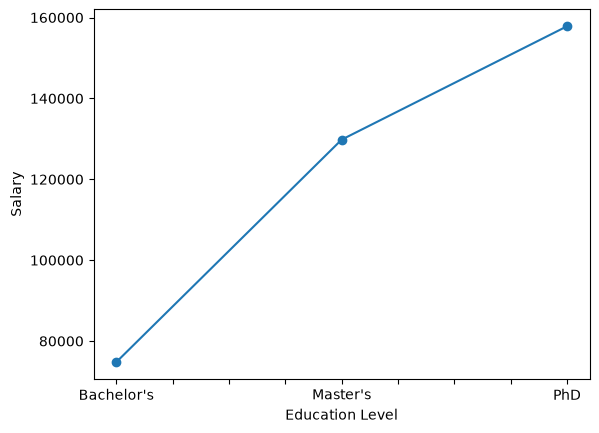

In [8]:
data.groupby('Education Level')['Salary'].mean().plot(marker='o')
mlp.xlabel('Education Level')
mlp.ylabel('Salary')

In [9]:
data.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [10]:
data['Education Level'].unique()

<StringArray>
['Bachelor's', 'Master's', 'PhD']
Length: 3, dtype: str

In [11]:
education_rank = {"Bachelor's":0,"Master's":1,"PhD":2}
data['education'] = data['Education Level'].map(education_rank)

In [12]:
data.drop(columns='Education Level', inplace=True)

In [13]:
data

,Age,Gender,Job Title,Years of Experience,Salary,education
0,32.0,Male,Software Engineer,5.0,90000.0,0
1,28.0,Female,Data Analyst,3.0,65000.0,1
2,45.0,Male,Senior Manager,15.0,150000.0,2
3,36.0,Female,Sales Associate,7.0,60000.0,0
4,52.0,Male,Director,20.0,200000.0,1
...,...,...,...,...,...,...
370,35.0,Female,Senior Marketing Analyst,8.0,85000.0,0
371,43.0,Male,Director of Operations,19.0,170000.0,1
372,29.0,Female,Junior Project Manager,2.0,40000.0,0
373,34.0,Male,Senior Operations Coordinator,7.0,90000.0,0


In [14]:
pd.get_dummies(data,columns=['Gender'],drop_first=True)

,Age,Job Title,Years of Experience,Salary,education,Gender_Male
0,32.0,Software Engineer,5.0,90000.0,0,True
1,28.0,Data Analyst,3.0,65000.0,1,False
2,45.0,Senior Manager,15.0,150000.0,2,True
3,36.0,Sales Associate,7.0,60000.0,0,False
4,52.0,Director,20.0,200000.0,1,True
...,...,...,...,...,...,...
370,35.0,Senior Marketing Analyst,8.0,85000.0,0,False
371,43.0,Director of Operations,19.0,170000.0,1,True
372,29.0,Junior Project Manager,2.0,40000.0,0,False
373,34.0,Senior Operations Coordinator,7.0,90000.0,0,True


In [15]:
data['Job Title'].nunique()
data['Job Title'].value_counts()

Job Title
Director of Marketing            12
Director of Operations           11
Senior Business Analyst          10
Senior Marketing Manager          9
Senior Marketing Analyst          9
                                 ..
Junior Research Scientist         1
Senior HR Specialist              1
Junior Operations Coordinator     1
Director of HR                    1
Junior Financial Advisor          1
Name: count, Length: 174, dtype: int64

In [16]:
title_counts = data['Job Title'].value_counts()
rare_titles = title_counts[title_counts<3].index

data['job title grouped'] = data['Job Title'].apply(lambda x : 'rare' if x in rare_titles else x )

In [17]:
rare_titles

Index(['Data Analyst', 'Senior Manager', 'Sales Associate',
       'Marketing Analyst', 'Product Manager', 'HR Manager', 'Project Manager',
       'Operations Manager', 'Senior Engineer', 'Business Analyst',
       ...
       'Junior UX Designer', 'Senior Marketing Director',
       'Junior Social Media Specialist', 'Senior Product Development Manager',
       'Senior Software Architect', 'Junior Research Scientist',
       'Senior HR Specialist', 'Junior Operations Coordinator',
       'Director of HR', 'Junior Financial Advisor'],
      dtype='str', name='Job Title', length=134)

In [18]:
data['job title grouped'].value_counts()

job title grouped
rare                                     163
Director of Marketing                     12
Director of Operations                    11
Senior Business Analyst                   10
Senior Marketing Manager                   9
Senior Marketing Analyst                   9
Junior Business Analyst                    8
Senior Data Scientist                      7
Senior Financial Analyst                   7
Senior Project Manager                     7
Junior Financial Analyst                   7
Junior Business Development Associate      7
Senior Software Engineer                   6
Senior Product Manager                     6
Junior Marketing Coordinator               6
Senior Project Coordinator                 5
Junior Operations Analyst                  5
Junior Marketing Specialist                5
Junior Project Manager                     5
Senior Product Designer                    5
Senior Operations Manager                  5
Senior Financial Manager             

In [19]:
data

,Age,Gender,Job Title,Years of Experience,Salary,education,job title grouped
0,32.0,Male,Software Engineer,5.0,90000.0,0,rare
1,28.0,Female,Data Analyst,3.0,65000.0,1,rare
2,45.0,Male,Senior Manager,15.0,150000.0,2,rare
3,36.0,Female,Sales Associate,7.0,60000.0,0,rare
4,52.0,Male,Director,20.0,200000.0,1,rare
...,...,...,...,...,...,...,...
370,35.0,Female,Senior Marketing Analyst,8.0,85000.0,0,Senior Marketing Analyst
371,43.0,Male,Director of Operations,19.0,170000.0,1,Director of Operations
372,29.0,Female,Junior Project Manager,2.0,40000.0,0,Junior Project Manager
373,34.0,Male,Senior Operations Coordinator,7.0,90000.0,0,Senior Operations Coordinator


In [20]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, drop='first',handle_unknown='ignore')

encoded_array = encoder.fit_transform(data[['job title grouped']])

encoded_cols = encoder.get_feature_names_out(['job title grouped'])

jobs = pd.DataFrame(encoded_array, columns=encoded_cols)

final = pd.concat([data,jobs],axis=1)

In [21]:
final.drop(columns=['Job Title','Gender','job title grouped'], inplace=True)

In [22]:
final

,Age,Years of Experience,Salary,education,job title grouped_Director of Operations,job title grouped_Junior Accountant,job title grouped_Junior Business Analyst,job title grouped_Junior Business Development Associate,job title grouped_Junior Financial Analyst,job title grouped_Junior Marketing Analyst,...,job title grouped_Senior Operations Manager,job title grouped_Senior Product Designer,job title grouped_Senior Product Manager,job title grouped_Senior Project Coordinator,job title grouped_Senior Project Manager,job title grouped_Senior Scientist,job title grouped_Senior Software Developer,job title grouped_Senior Software Engineer,job title grouped_Senior UX Designer,job title grouped_rare
0,32.0,5.0,90000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,28.0,3.0,65000.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,45.0,15.0,150000.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,36.0,7.0,60000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,52.0,20.0,200000.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,29.0,2.0,40000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
373,34.0,7.0,90000.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
374,44.0,15.0,150000.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


<Axes: xlabel='Salary', ylabel='Count'>

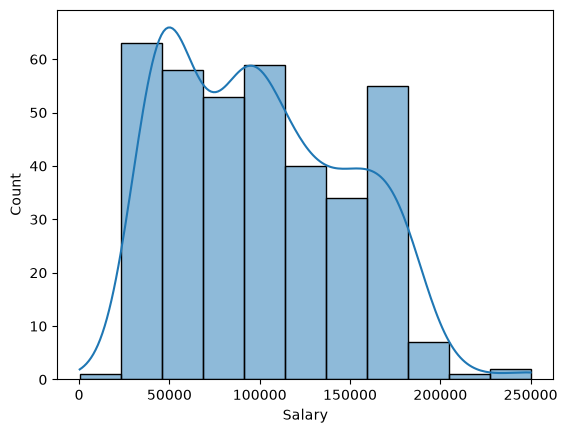

In [23]:
sb.histplot(data=final, x='Salary', kde=True)

<Axes: >

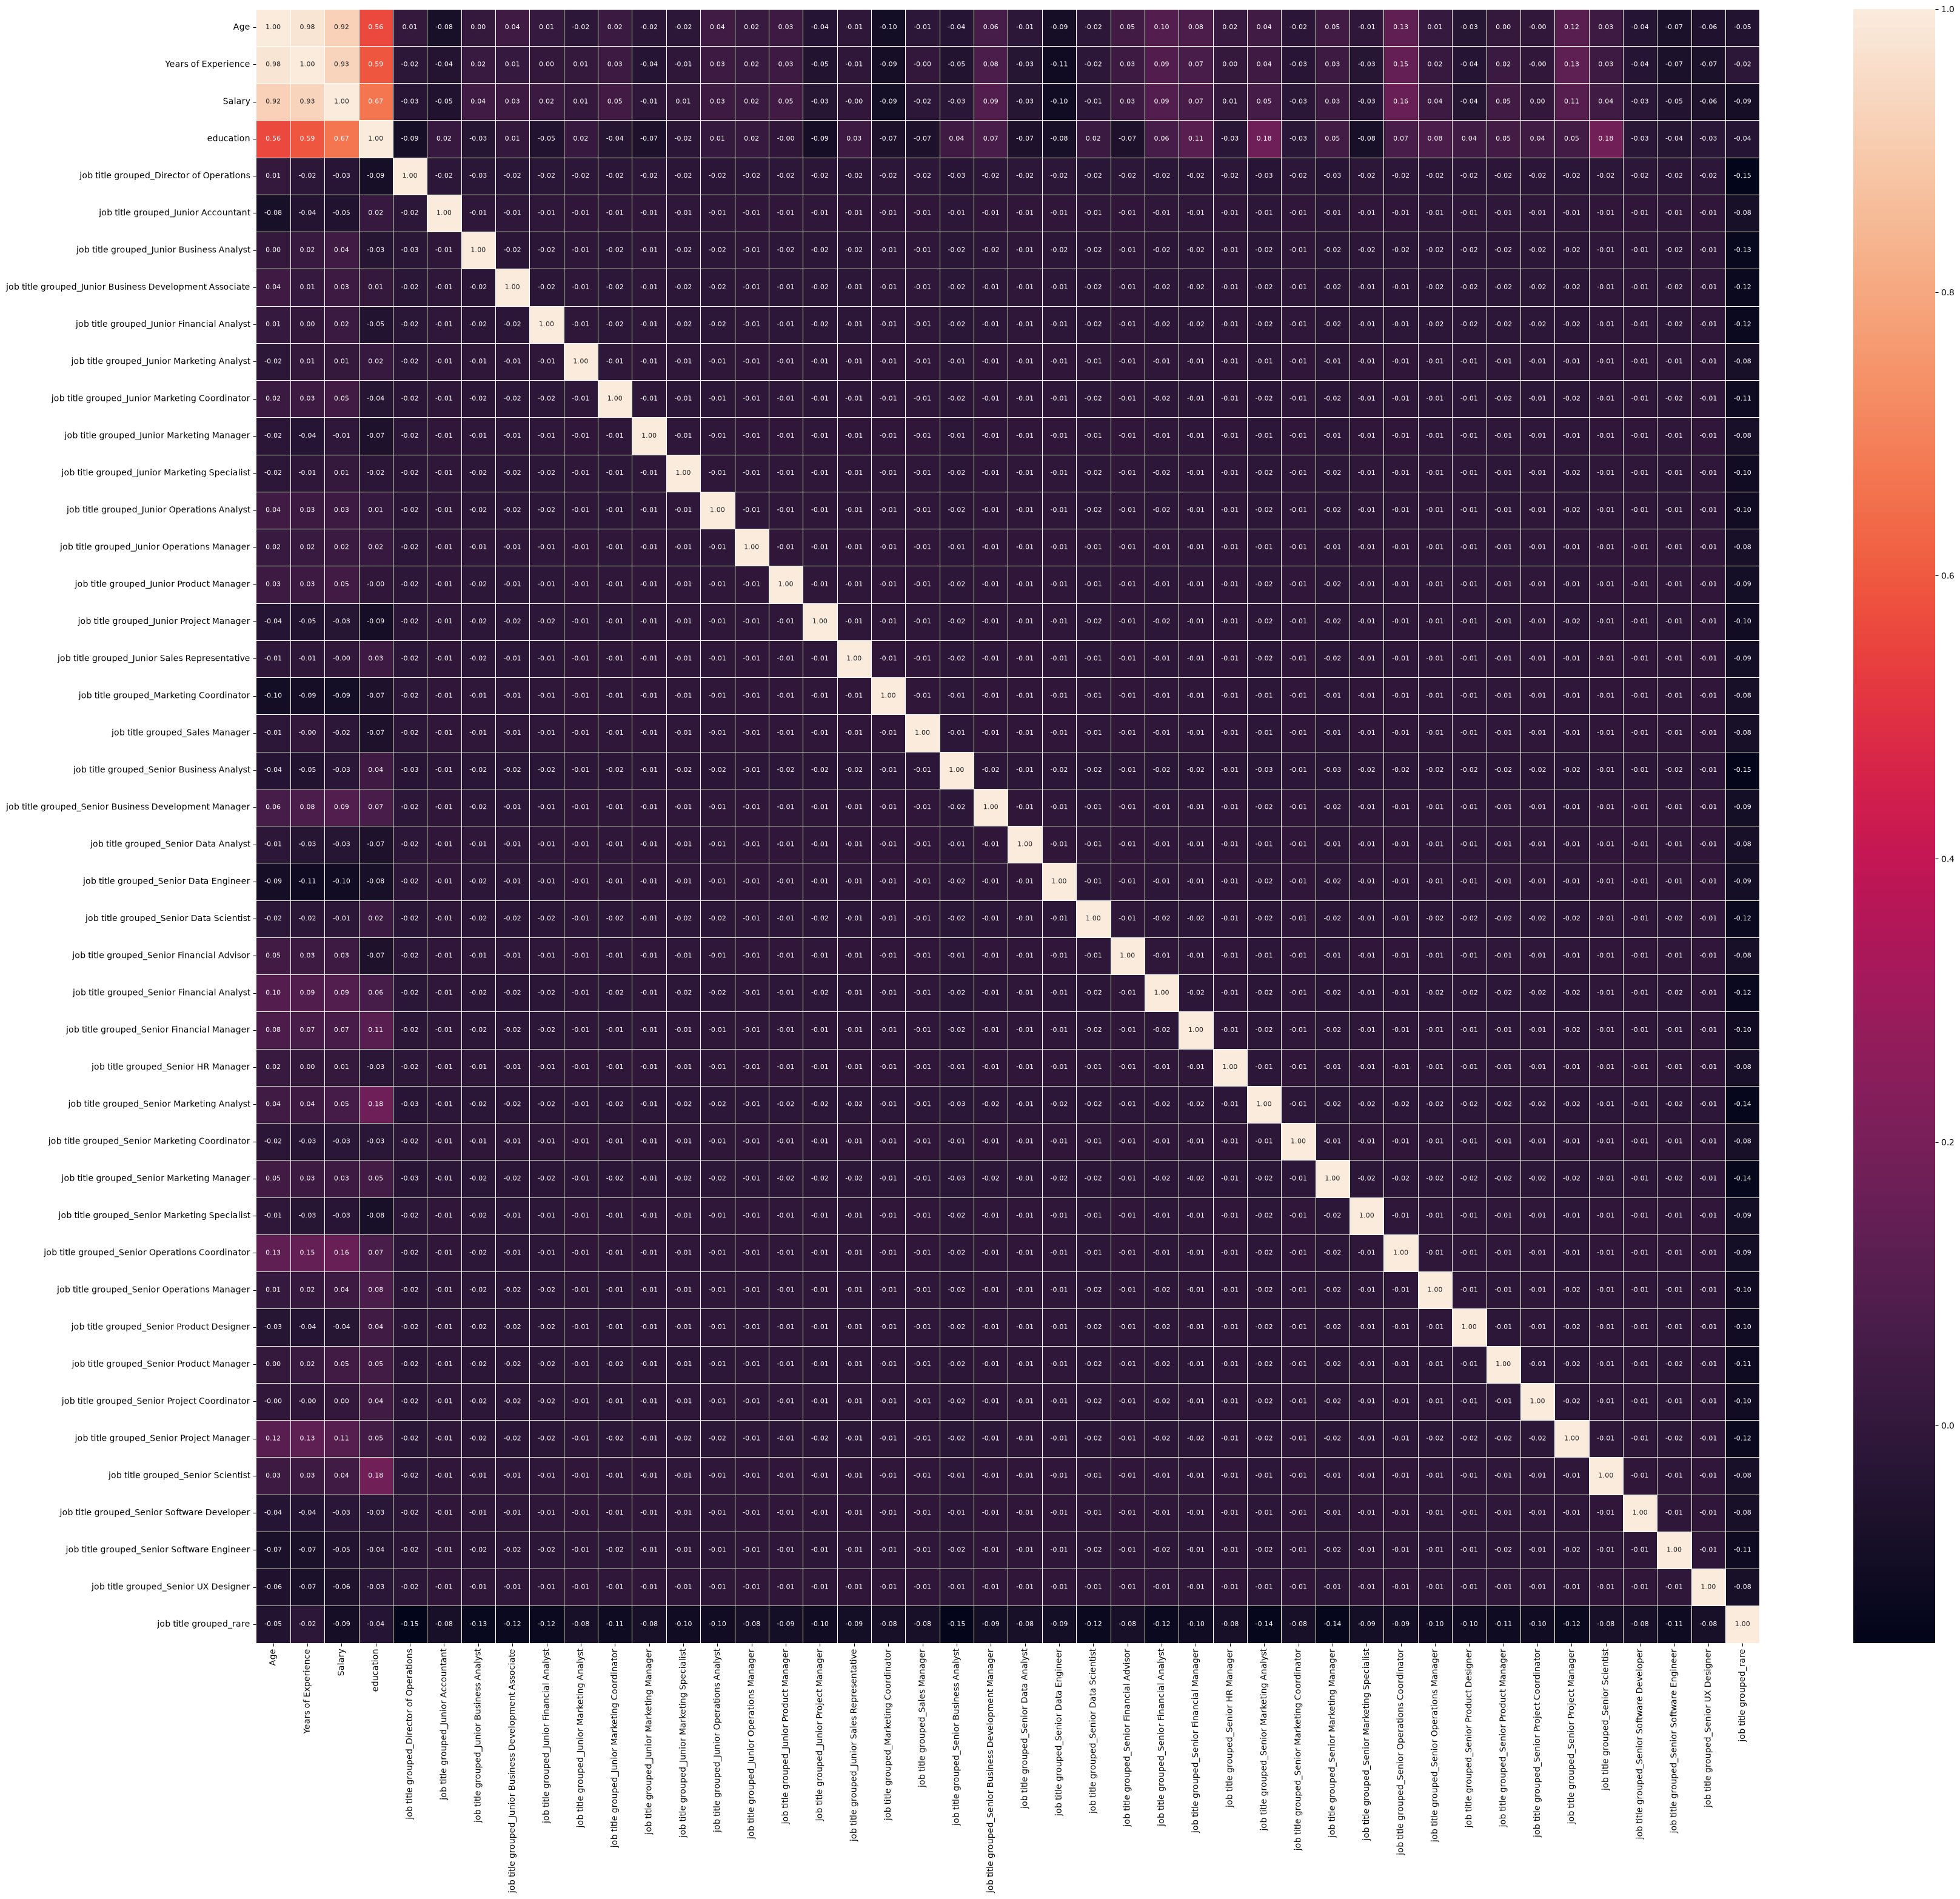

In [24]:
mlp.figure(figsize=(40,35))
sb.heatmap(final.corr(),annot=True,fmt='.2f',annot_kws={'size':8},linewidths=0.5,cbar=True)

In [25]:
data

,Age,Gender,Job Title,Years of Experience,Salary,education,job title grouped
0,32.0,Male,Software Engineer,5.0,90000.0,0,rare
1,28.0,Female,Data Analyst,3.0,65000.0,1,rare
2,45.0,Male,Senior Manager,15.0,150000.0,2,rare
3,36.0,Female,Sales Associate,7.0,60000.0,0,rare
4,52.0,Male,Director,20.0,200000.0,1,rare
...,...,...,...,...,...,...,...
370,35.0,Female,Senior Marketing Analyst,8.0,85000.0,0,Senior Marketing Analyst
371,43.0,Male,Director of Operations,19.0,170000.0,1,Director of Operations
372,29.0,Female,Junior Project Manager,2.0,40000.0,0,Junior Project Manager
373,34.0,Male,Senior Operations Coordinator,7.0,90000.0,0,Senior Operations Coordinator


In [26]:
new = data.groupby('job title grouped')['Salary'].agg(['mean','count']).sort_values('mean',ascending=True)
new

,mean,count
job title grouped,,
Junior Sales Representative,40000.000000,4
Junior Business Development Associate,40714.285714,7
Junior Accountant,41666.666667,3
Junior Marketing Coordinator,46666.666667,6
Junior Project Manager,47000.000000,5
Junior Marketing Analyst,48333.333333,3
Junior Business Analyst,50000.000000,8
Marketing Coordinator,50000.000000,3
Junior Operations Analyst,51000.000000,5


<Axes: xlabel='job title grouped', ylabel='mean'>

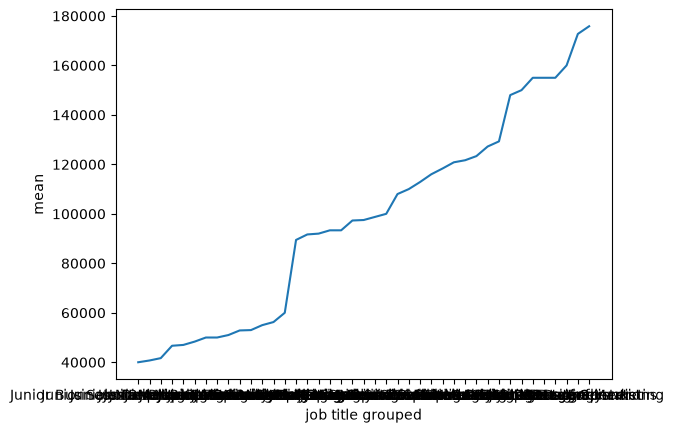

In [27]:
sb.lineplot(data=new,x='job title grouped' ,y='mean')

In [28]:
final

,Age,Years of Experience,Salary,education,job title grouped_Director of Operations,job title grouped_Junior Accountant,job title grouped_Junior Business Analyst,job title grouped_Junior Business Development Associate,job title grouped_Junior Financial Analyst,job title grouped_Junior Marketing Analyst,...,job title grouped_Senior Operations Manager,job title grouped_Senior Product Designer,job title grouped_Senior Product Manager,job title grouped_Senior Project Coordinator,job title grouped_Senior Project Manager,job title grouped_Senior Scientist,job title grouped_Senior Software Developer,job title grouped_Senior Software Engineer,job title grouped_Senior UX Designer,job title grouped_rare
0,32.0,5.0,90000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,28.0,3.0,65000.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,45.0,15.0,150000.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,36.0,7.0,60000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,52.0,20.0,200000.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,29.0,2.0,40000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
373,34.0,7.0,90000.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
374,44.0,15.0,150000.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
172,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [29]:
final.info()

<class 'pandas.DataFrame'>
Index: 375 entries, 0 to 260
Data columns (total 44 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Age                                                      373 non-null    float64
 1   Years of Experience                                      373 non-null    float64
 2   Salary                                                   373 non-null    float64
 3   education                                                373 non-null    float64
 4   job title grouped_Director of Operations                 373 non-null    float64
 5   job title grouped_Junior Accountant                      373 non-null    float64
 6   job title grouped_Junior Business Analyst                373 non-null    float64
 7   job title grouped_Junior Business Development Associate  373 non-null    float64
 8   job title grouped_Junior Financial Analyst    

In [30]:
final.drop(columns='Salary').shape

(375, 43)

In [31]:
final.dropna(axis=0,inplace=True)

In [32]:
x = (final.drop(columns='Salary').values)
y = (final['Salary'].values)

In [33]:
print(x.shape)
print(y.shape)

(371, 43)
(371,)


In [34]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [35]:
model = LinearRegression()

In [36]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](43,)","[ 2716.78, 2832.45, 16638.84,..., -2447.42,-11170.28,-10665.27]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.155e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,43
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(43)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](43,)","[155.5 , 16.18, 8.86,..., 0.99, 0.97, 0.4 ]"


In [37]:
y_pred = model.predict(x_test)

In [38]:
score = r2_score(y_test,y_pred)
score

0.8581993242086992

In [54]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mae = mean_absolute_error(y_test,y_pred)
print(f'Mean Absolute Error : {mae}')
mse = mean_squared_error(y_test,y_pred)
print(f'Mean Squared Error : {mse}')
print(f'R^2 Score : {score}')

Mean Absolute Error : 12699.34433502276
Mean Squared Error : 314650189.85482186
R^2 Score : 0.8581993242086992


In [39]:
x_test.shape

(112, 43)

In [ ]:
x_test.shape

(112, 43)

In [40]:
y_test.shape

(112,)

In [49]:
sorted_ind = np.argsort(x_test[:,0])
x_test_sorted = x_test[sorted_ind]
y_pred_sorted = y_pred[sorted_ind]

Text(0, 0.5, 'Salary')

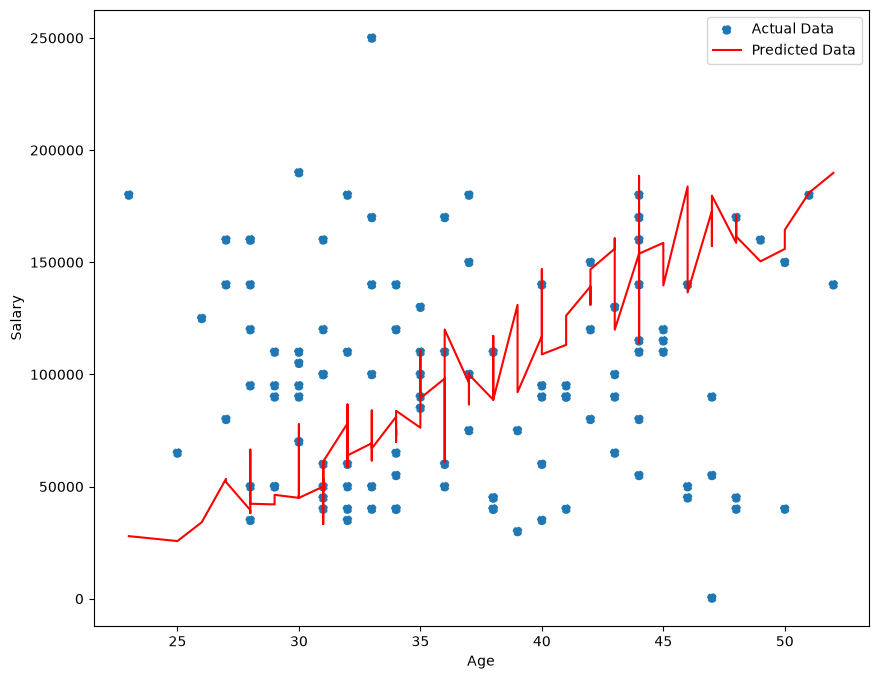

In [50]:
mlp.figure(figsize=(10,8))
mlp.scatter(x_test_sorted[:,0],y_test,label='Actual Data',linestyle='--')
mlp.plot(x_test_sorted[:,0],y_pred_sorted,label='Predicted Data',c='r')
mlp.legend()
mlp.xlabel('Age')
mlp.ylabel('Salary')